In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [2]:
train_data = datasets.CIFAR10(root='.data', train=True, download=True, transform=transforms.ToTensor())
test_data = datasets.CIFAR10(root='.data', train=False, download=True, transform=transforms.ToTensor())

100%|██████████| 170M/170M [00:06<00:00, 28.3MB/s]


In [3]:
Classes = train_data.classes

In [4]:
train = DataLoader(train_data, batch_size=64, shuffle=True)
test = DataLoader(test_data, batch_size=64)

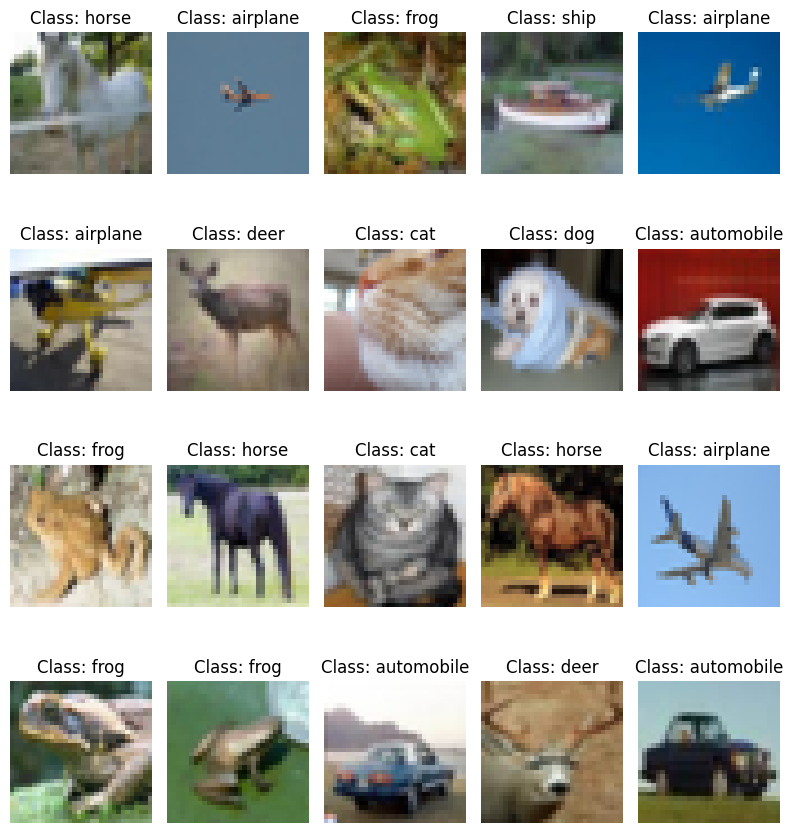

In [5]:
image, label = next(iter(train))
plt.figure(figsize=(8,10))
for i in range(20):
  plt.subplot(4, 5, i+1)
  plt.imshow(image[i].permute(1, 2, 0))
  plt.title(f'Class: {Classes[label[i]]}')
  plt.axis('off')
  plt.tight_layout()
plt.show()

In [6]:
class CifarClassifaction(nn.Module):
  def __init__(self):
    super().__init__()
    self.first = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.second = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128 * 4 * 4, 256),
        nn.ReLU(),
        nn.Linear(256, 10)
    )
  def forward(self, image):
    image = self.first(image)
    image = self.second(image)
    return image

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [8]:
model = CifarClassifaction().to(device)

In [9]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [10]:
for epoch in range(30):
  model.train()
  total_loss = 0
  for x_batch, y_batch in train:
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
    y_pred = model(x_batch)
    loss = loss_fn(y_pred, y_batch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  print(f'Эпоха: {epoch+1}, Потери: {total_loss}')

Эпоха: 1, Потери: 0
Эпоха: 2, Потери: 0
Эпоха: 3, Потери: 0
Эпоха: 4, Потери: 0
Эпоха: 5, Потери: 0
Эпоха: 6, Потери: 0
Эпоха: 7, Потери: 0
Эпоха: 8, Потери: 0
Эпоха: 9, Потери: 0
Эпоха: 10, Потери: 0
Эпоха: 11, Потери: 0
Эпоха: 12, Потери: 0
Эпоха: 13, Потери: 0
Эпоха: 14, Потери: 0
Эпоха: 15, Потери: 0
Эпоха: 16, Потери: 0
Эпоха: 17, Потери: 0
Эпоха: 18, Потери: 0
Эпоха: 19, Потери: 0
Эпоха: 20, Потери: 0
Эпоха: 21, Потери: 0
Эпоха: 22, Потери: 0
Эпоха: 23, Потери: 0
Эпоха: 24, Потери: 0
Эпоха: 25, Потери: 0
Эпоха: 26, Потери: 0
Эпоха: 27, Потери: 0
Эпоха: 28, Потери: 0
Эпоха: 29, Потери: 0
Эпоха: 30, Потери: 0


In [11]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
  for x_batch, y_batch in test:
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
    y_pred = model(x_batch)
    pred = torch.max(y_pred, dim=1)
    total += y_batch.size(0)
    correct += (pred.indices == y_batch).sum().item()
accuracy = 100 * correct/total
print(f'Accuracy: {accuracy} %')

Accuracy: 72.74 %


In [17]:
torch.save(model.state_dict(), 'model.pth')